# Olist E-Commerce Dataset Analysis

In [69]:
# ===================================
# Useful Imports: Add more as needed
# ===================================

# Standard Libraries
import os
import time
import math
import io
import zipfile
import requests
from urllib.parse import urlparse
from itertools import chain, combinations

# Data Science Libraries
import numpy as np
import pandas as pd
# !pip install statsmodels
import statsmodels.api as sm
import statsmodels.formula.api as smf



# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as mticker  # Optional: Format y-axis labels as dollars
import seaborn as sns

# Scikit-learn (Machine Learning)
from sklearn.model_selection import (
    train_test_split, 
    cross_val_score, 
    GridSearchCV, 
    RandomizedSearchCV, 
    RepeatedKFold
)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
from sklearn.feature_selection import SequentialFeatureSelector, f_regression, SelectKBest
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.decomposition import PCA

# Progress Tracking

# !pip install tqdm 
from tqdm import tqdm

# =============================
# Global Variables
# =============================
random_state = 0

# =============================
# Utility Functions
# =============================

# Format y-axis labels as dollars with commas (optional)
def dollar_format(x, pos):
    return f'${x:,.0f}'

# Convert seconds to HH:MM:SS format
def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))



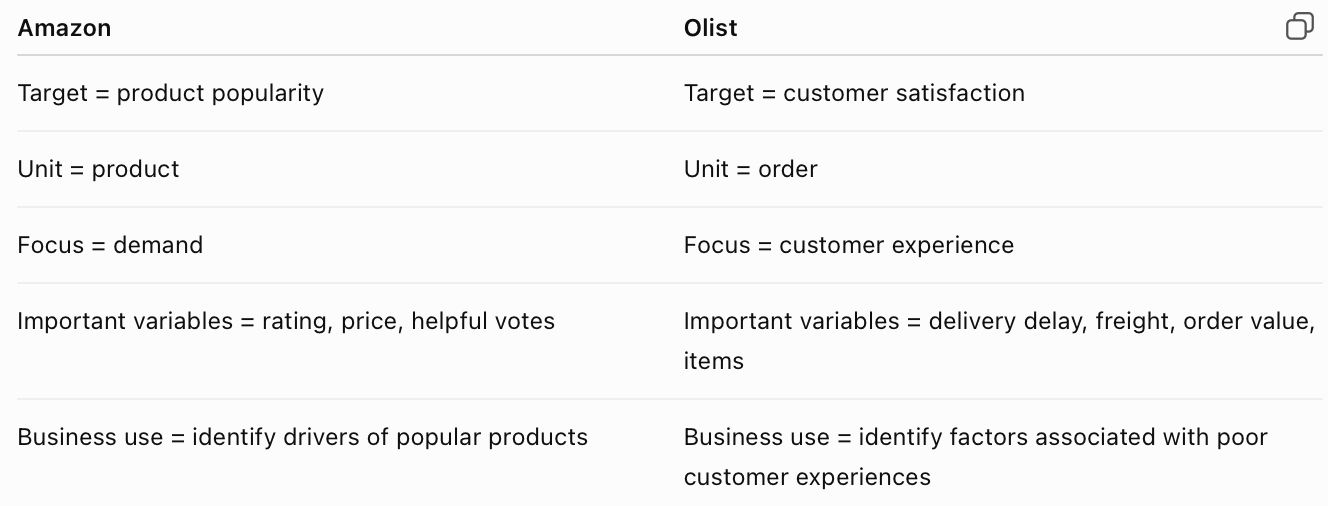
# Olist Dataset Question:
### To what extent can order, payment, and delivery characteristics predict whether an Olist customer leaves a positive review?

## Dataset Loading and Aggregation

In [70]:
#LOAD ALL 9 DATASETS 
customersdf = pd.read_csv('olist_customers_dataset.csv')
ordersdf = pd.read_csv('olist_orders_dataset.csv')
itemsdf = pd.read_csv('olist_order_items_dataset.csv')
paymentsdf = pd.read_csv('olist_order_payments_dataset.csv')
reviewsdf = pd.read_csv('olist_order_reviews_dataset.csv')
productsdf = pd.read_csv('olist_products_dataset.csv')
sellersdf = pd.read_csv('olist_sellers_dataset.csv')
geodf = pd.read_csv('olist_geolocation_dataset.csv')
translationdf = pd.read_csv('product_category_name_translation.csv')


In [71]:
#check column names of all dfs
for name, df in {
    "customers": customersdf,
    "orders": ordersdf,
    "items": itemsdf,
    "payments": paymentsdf,
    "reviews": reviewsdf,
    "products": productsdf,
    "sellers": sellersdf,
    "geo" : geodf,
    "translation" : translationdf
}.items():
    print(name, df.columns)


customers Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='object')
orders Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='object')
items Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value'],
      dtype='object')
payments Index(['order_id', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value'],
      dtype='object')
reviews Index(['review_id', 'order_id', 'review_score', 'review_comment_title',
       'review_comment_message', 'review_creation_date',
       'review_answer_timestamp'],
      dtype='object')
products Index(['product_id', 'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qt

In [72]:
#CREATE CENTRAL df -> MERGE on selected dfs (orders, items, products, payments, reviews, customers)

df = ordersdf.merge(itemsdf, on ='order_id')
df = df.merge(productsdf, on='product_id')
df = df.merge(paymentsdf, on='order_id')
df = df.merge(reviewsdf, on='order_id')
df = df.merge(customersdf, on='customer_id')
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,a54f0611adc9ed256b57ede6b6eb5114,4,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,a54f0611adc9ed256b57ede6b6eb5114,4,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,a54f0611adc9ed256b57ede6b6eb5114,4,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,595fac2a385ac33a80bd5114aec74eb8,...,8d5266042046a06655c8db133d120ba5,4,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,aa4383b373c6aca5d8797843e5594415,...,e73b67b67587f7644d5bd1a52deb1b01,5,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO


## 1)Pre-Processing

In [73]:
# info
olist_df = df.copy() #create copy

olist_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117329 entries, 0 to 117328
Data columns (total 36 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       117329 non-null  object 
 1   customer_id                    117329 non-null  object 
 2   order_status                   117329 non-null  object 
 3   order_purchase_timestamp       117329 non-null  object 
 4   order_approved_at              117314 non-null  object 
 5   order_delivered_carrier_date   116094 non-null  object 
 6   order_delivered_customer_date  114858 non-null  object 
 7   order_estimated_delivery_date  117329 non-null  object 
 8   order_item_id                  117329 non-null  int64  
 9   product_id                     117329 non-null  object 
 10  seller_id                      117329 non-null  object 
 11  shipping_limit_date            117329 non-null  object 
 12  price                         

In [74]:
#) check duplicaiton
df.shape # 117329, 36 features
df['order_id'].nunique()    #97916

#how many repeats of same order 
df['order_id'].value_counts().head(10)


order_id
895ab968e7bb0d5659d16cd74cd1650c    63
fedcd9f7ccdc8cba3a18defedd1a5547    38
fa65dad1b0e818e3ccc5cb0e39231352    29
ccf804e764ed5650cd8759557269dc13    26
465c2e1bee4561cb39e0db8c5993aafc    24
6d58638e32674bebee793a47ac4cbadc    24
c6492b842ac190db807c15aff21a7dd6    24
a3725dfe487d359b5be08cac48b64ec5    24
68986e4324f6a21481df4e6e89abcf01    24
285c2e15bebd4ac83635ccc563dc71f4    22
Name: count, dtype: int64

In [75]:
# Look at most repeated order
top_order = df['order_id'].value_counts().index[0]

df[df['order_id'] == top_order][[
    'order_id',
    'order_item_id',
    'product_id',
    'price',
    'payment_sequential',
    'payment_value',
    'review_id'
]]

,order_id,order_item_id,product_id,price,payment_sequential,payment_value,review_id
84228,895ab968e7bb0d5659d16cd74cd1650c,1,ebf9bc6cd600eadd681384e3116fda85,12.99,17,16.70,eef5dbca8d37dfce6db7d7b16dd0525e
84229,895ab968e7bb0d5659d16cd74cd1650c,1,ebf9bc6cd600eadd681384e3116fda85,12.99,1,2.61,eef5dbca8d37dfce6db7d7b16dd0525e
84230,895ab968e7bb0d5659d16cd74cd1650c,1,ebf9bc6cd600eadd681384e3116fda85,12.99,13,16.70,eef5dbca8d37dfce6db7d7b16dd0525e
84231,895ab968e7bb0d5659d16cd74cd1650c,1,ebf9bc6cd600eadd681384e3116fda85,12.99,16,16.70,eef5dbca8d37dfce6db7d7b16dd0525e
84232,895ab968e7bb0d5659d16cd74cd1650c,1,ebf9bc6cd600eadd681384e3116fda85,12.99,19,0.24,eef5dbca8d37dfce6db7d7b16dd0525e
...,...,...,...,...,...,...,...
84286,895ab968e7bb0d5659d16cd74cd1650c,3,5ddab10d5e0a23acb99acf56b62b3276,83.80,15,16.70,eef5dbca8d37dfce6db7d7b16dd0525e
84287,895ab968e7bb0d5659d16cd74cd1650c,3,5ddab10d5e0a23acb99acf56b62b3276,83.80,20,4.61,eef5dbca8d37dfce6db7d7b16dd0525e
84288,895ab968e7bb0d5659d16cd74cd1650c,3,5ddab10d5e0a23acb99acf56b62b3276,83.80,14,16.70,eef5dbca8d37dfce6db7d7b16dd0525e
84289,895ab968e7bb0d5659d16cd74cd1650c,3,5ddab10d5e0a23acb99acf56b62b3276,83.80,9,2.61,eef5dbca8d37dfce6db7d7b16dd0525e


In [76]:
#NOTE - only 3 order items but x 21 payment records
df[df['order_id'] == top_order][
    ['order_item_id', 'payment_sequential']
].drop_duplicates()

,order_item_id,payment_sequential
84228,1,17
84229,1,1
84230,1,13
84231,1,16
84232,1,19
...,...,...
84286,3,15
84287,3,20
84288,3,14
84289,3,9


### Cleaning up Tables again BEFORE MERGE analysis_df
### Goal = 1 order_id per row

In [78]:
# 1) AGGREGATE ORDER ITEMS
items_agg = itemsdf.groupby('order_id').agg(
    total_price=('price', 'sum'),
    total_freight=('freight_value', 'sum'),
    num_items=('order_item_id', 'count')
).reset_index()


# 2) AGGREGATE PAYMENTS
payments_agg = paymentsdf.groupby('order_id').agg(
    total_payment=('payment_value', 'sum'),
    num_payments=('payment_sequential', 'count'),
    payment_installments=('payment_installments', 'max')
).reset_index()


# 3) AGGREGATE REVIEWS
reviews_agg = reviewsdf.groupby('order_id').agg(
    review_score=('review_score', 'mean')
).reset_index()


# 4) GET PRIMARY PAYMENT TYPE
primary_payment = (
    paymentsdf
    .sort_values('payment_value', ascending=False)
    .drop_duplicates('order_id')
    [['order_id', 'payment_type']]
    .rename(columns={'payment_type': 'primary_payment_type'})
)


# 5) GET PRIMARY PRODUCT CATEGORY
items_products = itemsdf.merge(
    productsdf[['product_id', 'product_category_name']],
    on='product_id',
    how='left'
)

#6) Translate items_products
items_products = items_products.merge(
    translationdf,
    on='product_category_name',
    how='left'
)

primary_category = (
    items_products
    .sort_values('price', ascending=False)
    .drop_duplicates('order_id')
    [['order_id', 'product_category_name_english']]
    .rename(columns={'product_category_name_english': 'primary_product_category'})
)
display(primary_category)

,order_id,primary_product_category
3556,0812eb902a67711a1cb742b3cdaa65ae,housewares
112233,fefacc66af859508bf1a7934eab1e97f,computers
107841,f5136e38d1a14a4dbd87dff67da82701,art
74336,a96610ab360d42a2e5335a3998b4718a,small_appliances
11249,199af31afc78c699f0dbf71fb178d4d4,small_appliances
...,...,...
24916,38bcb524e1c38c2c1b60600a80fc8999,pet_shop
102500,e8bbc1d69fee39eee4c72cb5c969e39d,stationery
106405,f1d5c2e6867fa93ceee9ef9b34a53cbf,health_beauty
48625,6e864b3f0ec71031117ad4cf46b7f2a1,construction_tools_construction


In [80]:
# 6) Create analysis_df FINAL ORDER-LEVEL
analysis_df = ordersdf.merge(items_agg, on='order_id', how='left')

analysis_df = analysis_df.merge(
    payments_agg, on='order_id', how='left'
)

analysis_df = analysis_df.merge(
    reviews_agg, on='order_id', how='left'
)

analysis_df = analysis_df.merge(
    customersdf, on='customer_id', how='left'
)

#primary payment
analysis_df = analysis_df.merge(
    primary_payment, on='order_id', how='left'
)

#primary category
analysis_df = analysis_df.merge(
    primary_category, on='order_id', how='left'
)


In [81]:
#Display analysis_df
display(
    analysis_df.head(),
    analysis_df.info(),
    analysis_df.shape,
    analysis_df['order_id'].nunique()
)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 21 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       99441 non-null  object 
 1   customer_id                    99441 non-null  object 
 2   order_status                   99441 non-null  object 
 3   order_purchase_timestamp       99441 non-null  object 
 4   order_approved_at              99281 non-null  object 
 5   order_delivered_carrier_date   97658 non-null  object 
 6   order_delivered_customer_date  96476 non-null  object 
 7   order_estimated_delivery_date  99441 non-null  object 
 8   total_price                    98666 non-null  float64
 9   total_freight                  98666 non-null  float64
 10  num_items                      98666 non-null  float64
 11  total_payment                  99440 non-null  float64
 12  num_payments                   99440 non-null 

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,total_price,total_freight,...,total_payment,num_payments,payment_installments,review_score,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,primary_payment_type,primary_product_category
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,29.99,8.72,...,38.71,3.0,1.0,4.0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,voucher,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,118.70,22.76,...,141.46,1.0,1.0,4.0,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,boleto,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,159.90,19.22,...,179.12,1.0,3.0,5.0,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,credit_card,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,45.00,27.20,...,72.20,1.0,1.0,5.0,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,credit_card,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,19.90,8.72,...,28.62,1.0,1.0,5.0,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,credit_card,stationery


None

(99441, 21)

99441

In [82]:
#final df cleaned

#Now all rows = 1 order id
analysis_df['order_id'].nunique()

99441

## --2) Feature Engineering Section--

In [83]:
analysis_df.shape # 99441, 21

analysis_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 21 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       99441 non-null  object 
 1   customer_id                    99441 non-null  object 
 2   order_status                   99441 non-null  object 
 3   order_purchase_timestamp       99441 non-null  object 
 4   order_approved_at              99281 non-null  object 
 5   order_delivered_carrier_date   97658 non-null  object 
 6   order_delivered_customer_date  96476 non-null  object 
 7   order_estimated_delivery_date  99441 non-null  object 
 8   total_price                    98666 non-null  float64
 9   total_freight                  98666 non-null  float64
 10  num_items                      98666 non-null  float64
 11  total_payment                  99440 non-null  float64
 12  num_payments                   99440 non-null 

In [84]:
analysis_df[
    ['primary_payment_type', 'primary_product_category']
].head(10)

,primary_payment_type,primary_product_category
0,voucher,housewares
1,boleto,perfumery
2,credit_card,auto
3,credit_card,pet_shop
4,credit_card,stationery
5,credit_card,auto
6,credit_card,NaN
7,credit_card,auto
8,boleto,furniture_decor
9,voucher,office_furniture


In [85]:
analysis_df['primary_payment_type'].value_counts(dropna=False)

analysis_df['primary_product_category'].nunique()

71

In [86]:
# convert dates to datetime
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_cols:
    analysis_df[col] = pd.to_datetime(analysis_df[col])

#### Create useful features = "delivery_days", "delivery_delay", "late_delivery", "purchase_month", "purchase_dayofweek" 

In [87]:
# Days from purchase → delivery
analysis_df['delivery_days'] = (
    analysis_df['order_delivered_customer_date'] -
    analysis_df['order_purchase_timestamp']
).dt.days

# Difference between actual and estimated delivery
analysis_df['delivery_delay'] = (
    analysis_df['order_delivered_customer_date'] -
    analysis_df['order_estimated_delivery_date']
).dt.days

    #delay < 0 = arrived early, >0  = arrived late

#create late_delivery
analysis_df['late_delivery'] = (
    analysis_df['delivery_delay'] > 0
).astype(int)

#purchase-time features
analysis_df['purchase_month'] = (
    analysis_df['order_purchase_timestamp'].dt.month
)

analysis_df['purchase_dayofweek'] = (
    analysis_df['order_purchase_timestamp'].dt.dayofweek
)

### Check Statistics

In [88]:
#check statistics 
analysis_df.describe()

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,total_price,total_freight,num_items,total_payment,num_payments,payment_installments,review_score,customer_zip_code_prefix,delivery_days,delivery_delay,late_delivery,purchase_month,purchase_dayofweek
count,99441,99281,97658,96476,99441,98666.000000,98666.000000,98666.000000,99440.000000,99440.000000,99440.000000,98673.000000,99441.000000,96476.000000,96476.000000,99441.000000,99441.000000,99441.000000
mean,2017-12-31 08:43:12.776581120,2017-12-31 18:35:24.098800128,2018-01-04 21:49:48.138278656,2018-01-14 12:09:19.035542272,2018-01-24 03:08:37.730111232,137.754076,22.823562,1.141731,160.990267,1.044710,2.930521,4.086793,35137.474583,12.094086,-11.876881,0.065717,6.032220,2.755735
min,2016-09-04 21:15:19,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-09-30 00:00:00,0.850000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1003.000000,0.000000,-147.000000,0.000000,1.000000,0.000000
25%,2017-09-12 14:46:19,2017-09-12 23:24:16,2017-09-15 22:28:50.249999872,2017-09-25 22:07:22.249999872,2017-10-03 00:00:00,45.900000,13.850000,1.000000,62.010000,1.000000,1.000000,4.000000,11347.000000,6.000000,-17.000000,0.000000,3.000000,1.000000
50%,2018-01-18 23:04:36,2018-01-19 11:36:13,2018-01-24 16:10:58,2018-02-02 19:28:10.500000,2018-02-15 00:00:00,86.900000,17.170000,1.000000,105.290000,1.000000,2.000000,5.000000,24416.000000,10.000000,-12.000000,0.000000,6.000000,3.000000
75%,2018-05-04 15:42:16,2018-05-04 20:35:10,2018-05-08 13:37:45,2018-05-15 22:48:52.249999872,2018-05-25 00:00:00,149.900000,24.040000,1.000000,176.970000,1.000000,4.000000,5.000000,58900.000000,15.000000,-7.000000,0.000000,8.000000,4.000000
max,2018-10-17 17:30:18,2018-09-03 17:40:06,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-11-12 00:00:00,13440.000000,1794.960000,21.000000,13664.080000,29.000000,24.000000,5.000000,99990.000000,209.000000,188.000000,1.000000,12.000000,6.000000
std,NaN,NaN,NaN,NaN,NaN,210.645145,21.650909,0.538452,221.951257,0.381166,2.715685,1.346274,29797.938996,9.551746,10.183854,0.247789,3.232999,1.966495


In [89]:
analysis_df['order_status'].value_counts()
    #about 3000 orders not delivered

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [90]:
analysis_df['customer_state'].value_counts().head()
    #most from Sao Paulo

customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
Name: count, dtype: int64

In [91]:
analysis_df['review_score'].value_counts().sort_index()

review_score
1.000000    11316
1.500000        8
2.000000     3125
2.500000       34
3.000000     8136
3.333333        1
3.500000       25
4.000000    19018
4.333333        1
4.500000       54
5.000000    56955
Name: count, dtype: int64

### CREATE BINARY CLASSIFICATION (positive review = >=4)

In [92]:
# 1 = positive review (4 or higher)
# 0 = negative/neutral review (below 4)
analysis_df['positive_review'] = (
    analysis_df['review_score'] >= 4
).astype(int)

In [93]:
#class balance
analysis_df['positive_review'].value_counts()
analysis_df['positive_review'].value_counts(normalize=True)

positive_review
1    0.764554
0    0.235446
Name: proportion, dtype: float64

### CREATE model_df to use for modeling, analysis_df for EDA
- because missing review scores makes them 0, impacts modeling 

In [94]:
#model_df
model_df = analysis_df.dropna(subset=['review_score']).copy()

#target
model_df['positive_review'] = (
    model_df['review_score'] >= 4
).astype(int)

display(
    model_df['positive_review'].value_counts(),
    model_df['positive_review'].value_counts(normalize=True)
)

positive_review
1    76028
0    22645
Name: count, dtype: int64

positive_review
1    0.770505
0    0.229495
Name: proportion, dtype: float64

## Summary: Olist Order-Level Data Preparation

- Combined Olist order, item, payment, review, and customer data.
- Identified duplicate order IDs caused by one-to-many relationships between orders, items, payments, and reviews.
- Aggregated order items and payments before merging to prevent many-to-many row multiplication.
- Aggregated multiple reviews to one review score per order.
- Created `analysis_df` with one row per unique order (99,441 orders).
- Converted delivery timestamps for subsequent feature engineering.
- Identified a small number of anomalous delivery timestamps for later consideration.
- Created `model_df` for modeling, with no NaN review_score, and `positive_review` target feature ('review_score' >=4)
    - 77.1% positive

## 3) --EDA Section --

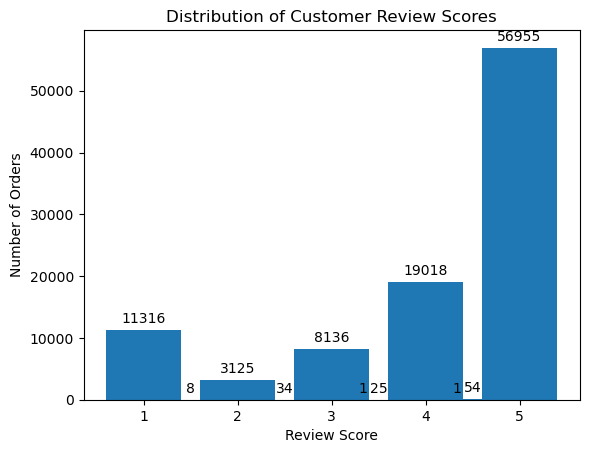

In [95]:
# EDA Figure 1: Review Score Distribution

review_counts = analysis_df['review_score'].value_counts().sort_index()

bars = plt.bar(review_counts.index, review_counts.values)

plt.xlabel('Review Score')
plt.ylabel('Number of Orders')
plt.title('Distribution of Customer Review Scores')
plt.xticks([1, 2, 3, 4, 5])

# Add percentage labels
plt.bar_label(
    bars,
    labels=[f'{x}' for x in review_counts.values],
    padding=3
)

plt.show()

### Do late deliveries affect positive reviews?

In [96]:
# Positive review rate by delivery status
late_review_rate = (
    model_df
    .dropna(subset=['delivery_delay']) #bc Nan here = 0 for late_delivery, affects averages
    .groupby('late_delivery')['positive_review']
    .agg(['mean', 'count'])
)
late_review_rate
#82% pos reviews for on-time/early, 26% positive reviews for late delivery

,mean,count
late_delivery,,
0,0.826335,89448
1,0.267314,6382


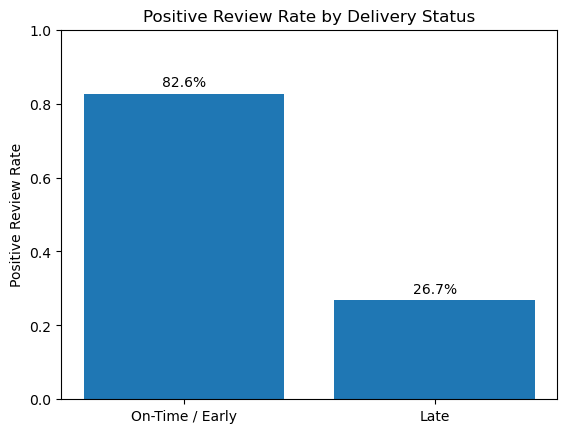

In [97]:
# EDA Figure 2: Review Rate by Delivery Status
delivery_review = (
    model_df
    .dropna(subset=['delivery_delay'])
    .groupby('late_delivery')['positive_review']
    .mean()
)

bars = plt.bar(
    ['On-Time / Early', 'Late'],
    delivery_review.values
)

plt.ylabel('Positive Review Rate')
plt.title('Positive Review Rate by Delivery Status')
plt.ylim(0, 1)

# Add percentage labels
plt.bar_label(
    bars,
    labels=[f'{x:.1%}' for x in delivery_review.values],
    padding=3
)

plt.show()

### Does "how late" matter?

In [98]:
#All review scores, with average delay values
model_df.groupby('review_score')['delivery_delay'].mean()

review_score
1.000000    -4.026191
1.500000    -6.000000
2.000000    -8.635460
2.500000    -7.566667
3.000000   -10.779687
3.333333   -14.000000
3.500000   -13.956522
4.000000   -12.379584
4.333333   -11.000000
4.500000   -13.037736
5.000000   -13.383435
Name: delivery_delay, dtype: float64

In [99]:
# Keep standard review scores (1-5)
review_delay = (
    model_df[model_df['review_score'].isin([1, 2, 3, 4, 5])]
    .groupby('review_score')['delivery_delay']
    .mean()
)
review_delay

review_score
1.0    -4.026191
2.0    -8.635460
3.0   -10.779687
4.0   -12.379584
5.0   -13.383435
Name: delivery_delay, dtype: float64

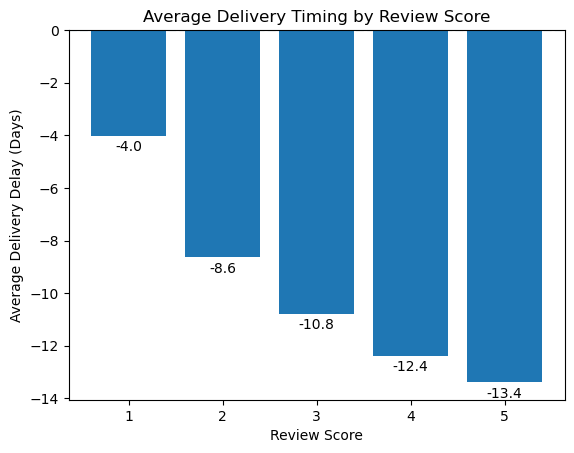

In [100]:
# EDA Figure 3 - Average Delivery Timing by Review Score

#Keep only standard 1–5 review scores
review_delay = (
    model_df[model_df['review_score'].isin([1, 2, 3, 4, 5])]
    .groupby('review_score')['delivery_delay']
    .mean()
)

bars = plt.bar(
    review_delay.index,
    review_delay.values
)

plt.xlabel('Review Score')
plt.ylabel('Average Delivery Delay (Days)')
plt.title('Average Delivery Timing by Review Score')
plt.xticks([1, 2, 3, 4, 5])

# Reference line: 0 = estimated delivery date
plt.axhline(0, linestyle='--')

plt.bar_label(
    bars,
    labels=[f'{x:.1f}' for x in review_delay.values],
    padding=3
)

plt.show()

In [101]:
#Check positive review distribution for all featurews
model_df.groupby('positive_review')[
    ['total_price',
     'total_freight',
     'num_items',
     'total_payment',
     'payment_installments',
     'delivery_days',
     'delivery_delay']
].mean().T

positive_review,0,1
total_price,149.393563,134.099401
total_freight,25.994663,21.879883
num_items,1.245555,1.110516
total_payment,176.633152,155.987593
payment_installments,3.081258,2.882491
delivery_days,17.407768,10.621595
delivery_delay,-7.354330,-13.132690


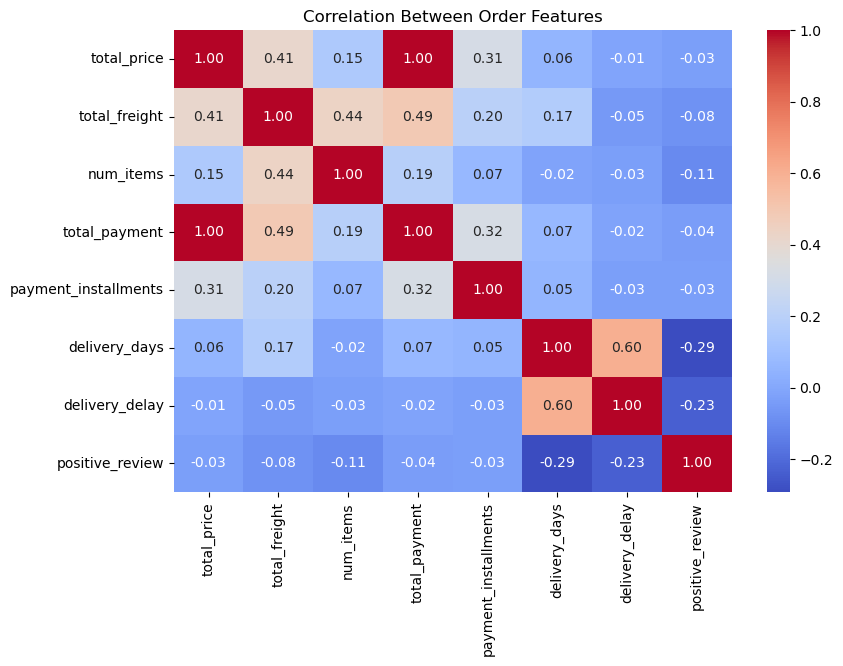

In [102]:
# Numeric features
corr_cols = [
    'total_price',
    'total_freight',
    'num_items',
    'total_payment',
    'payment_installments',
    'delivery_days',
    'delivery_delay',
    'positive_review'
]

corr = model_df[corr_cols].corr()

plt.figure(figsize=(9, 6))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Between Order Features')
plt.show()

- total_price ↔ total_payment = 1.00 → essentially redundant. Can drop total_payment from ML and keep total_price.
- delivery_days ↔ positive review = −0.29 → strongest linear relationship with the target.
- delivery_delay ↔ positive review = −0.23 → also meaningful.
- Price, freight, installments, etc. individually have fairly weak linear relationships with satisfaction.
- delivery_days and delivery_delay correlate at 0.60 --> overall wait time vs whether Olist met its promised date.
- TLDR = delivery performance seems to have more association with customer satisfaction than order cost/payment features.

## 4) -- Machine Learning Section --

### features + target

In [103]:
numeric_features = [  #6 
    'total_price',  #price
    'total_freight',    #shipping cost
    'num_items',    #order size
    'payment_installments', #payment behavior
    'delivery_days',    #overall delivery speed
    'delivery_delay'    #performance
]

categorical_features = [
    'primary_payment_type',
    'primary_product_category',
    'customer_state',
    'purchase_month',
    'purchase_dayofweek'
]

features = numeric_features + categorical_features
target = 'positive_review'

In [104]:
# Keep only orders with known delivery outcomes
model_df = model_df.dropna(
    subset=['delivery_days', 'delivery_delay']
).copy()

# Build X and y
X = model_df[features].copy()
y = model_df[target].copy()

X.shape, y.shape    #95830 rows

((95830, 11), (95830,))

In [105]:
#SPLIT DATA
# 2) TRAIN / TEST SPLIT

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=0,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

print("\nTrain target:")
print(y_train.value_counts(normalize=True))

print("\nTest target:")
print(y_test.value_counts(normalize=True))

Train: (76664, 11)
Test: (19166, 11)

Train target:
positive_review
1    0.789106
0    0.210894
Name: proportion, dtype: float64

Test target:
positive_review
1    0.789106
0    0.210894
Name: proportion, dtype: float64


In [106]:
# 3) Impute NaN with median, one-hot encode categorical

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Numeric features
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())    #good for regression
])

# Categorical features
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(
        strategy='constant',
        fill_value='Unknown'    #unknown value
    )),
    ('onehot', OneHotEncoder(
        handle_unknown='ignore'
    ))
])

# Combine numeric + categorical preprocessing
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

### Logistic Regression

In [107]:
# 1) LOGISTIC REGRESSION BASELINE

from sklearn.linear_model import LogisticRegression

log_model = Pipeline([
    ('preprocessor', preprocessor), #transform num and cat
    ('model', LogisticRegression(
        max_iter=1000,
        random_state=0
    ))
])

log_model.fit(X_train, y_train)

# Predictions
y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:, 1]

In [108]:
#Evaluate
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
log_results = {
    'Model': 'Logistic Regression',
    'Accuracy': accuracy_score(y_test, y_pred_log),
    'Precision': precision_score(y_test, y_pred_log),
    'Recall': recall_score(y_test, y_pred_log),
    'F1': f1_score(y_test, y_pred_log),
    'ROC-AUC': roc_auc_score(y_test, y_prob_log)
}
log_results

{'Model': 'Logistic Regression',
 'Accuracy': 0.8130021913805697,
 'Precision': 0.8192077893339235,
 'Recall': 0.9791060565987834,
 'F1': 0.8920481927710844,
 'ROC-AUC': 0.6965984051877399}

- good at identifying positive reviews 97.9%
- bad at classify non-positive = only 776/4042 correct
- SMALL IMPROVEMENT from baseline -> 77% -> 81.3% 

In [109]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred_log)

array([[  774,  3268],
       [  316, 14808]])

### Random Forest

In [110]:
# RANDOM FOREST

from sklearn.ensemble import RandomForestClassifier

# Preprocessing for tree models
tree_numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

tree_categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(
        strategy='constant',
        fill_value='Unknown'
    )),
    ('onehot', OneHotEncoder(
        handle_unknown='ignore',
        sparse_output=False
    ))
])

tree_preprocessor = ColumnTransformer([
    ('num', tree_numeric_transformer, numeric_features),
    ('cat', tree_categorical_transformer, categorical_features)
])


In [111]:
#build and train
rf_model = Pipeline([
    ('preprocessor', tree_preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        random_state=0,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [112]:
#results
rf_results = {
    'Model': 'Random Forest',
    'Accuracy': accuracy_score(y_test, y_pred_rf),
    'Precision': precision_score(y_test, y_pred_rf),
    'Recall': recall_score(y_test, y_pred_rf),
    'F1': f1_score(y_test, y_pred_rf),
    'ROC-AUC': roc_auc_score(y_test, y_prob_rf)
}

rf_results

{'Model': 'Random Forest',
 'Accuracy': 0.822602525305228,
 'Precision': 0.825811471765229,
 'Recall': 0.9824120603015075,
 'F1': 0.8973305954825462,
 'ROC-AUC': 0.6965674880823556}

- 0.69 ROC-AUC similar, suggests adding nonlinear relationships hasn't dramatically improved the model's ability to separate positive from non-positive reviews.

### Gradient Boosting

In [113]:
from sklearn.ensemble import HistGradientBoostingClassifier

gb_model = Pipeline([
    ('preprocessor', tree_preprocessor),
    ('model', HistGradientBoostingClassifier(
        learning_rate=0.1,
        max_iter=200,
        max_leaf_nodes=31,
        random_state=0
    ))
])

gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)
y_prob_gb = gb_model.predict_proba(X_test)[:, 1]

In [114]:
#results
gb_results = {
    'Model': 'Gradient Boosting',
    'Accuracy': accuracy_score(y_test, y_pred_gb),
    'Precision': precision_score(y_test, y_pred_gb),
    'Recall': recall_score(y_test, y_pred_gb),
    'F1': f1_score(y_test, y_pred_gb),
    'ROC-AUC': roc_auc_score(y_test, y_prob_gb)
}

gb_results

{'Model': 'Gradient Boosting',
 'Accuracy': 0.822602525305228,
 'Precision': 0.8256304855016109,
 'Recall': 0.98274266067178,
 'F1': 0.8973615890841031,
 'ROC-AUC': 0.7063543305082406}

- Models achieved moderate discrimination of positive versus non-positive reviews, with Gradient Boosting reaching ROC-AUC ≈ 0.706. Performance suggests that order, product, geographic, payment, time, and delivery characteristics contain predictive information, but do not fully explain customer review outcomes.

#### What Factors are most associated with satisfaction?

In [115]:
#GB permutation importances
from sklearn.inspection import permutation_importance

#randomly shuffle 1 feature, recalculate ROC-AUC 
#to see its importance
perm_importance = permutation_importance(
    gb_model,
    X_test,
    y_test,
    scoring='roc_auc',
    n_repeats=5,
    random_state=0,
    n_jobs=-1
)
#create df
importance_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance': perm_importance.importances_mean,
    'Std': perm_importance.importances_std
}).sort_values(
    'Importance',
    ascending=False
)

importance_df

,Feature,Importance,Std
4,delivery_days,0.045583,0.003575
5,delivery_delay,0.039294,0.002183
2,num_items,0.038658,0.003490
7,primary_product_category,0.010790,0.000997
0,total_price,0.004155,0.000791
1,total_freight,0.004032,0.000364
3,payment_installments,0.001293,0.000584
8,customer_state,0.001061,0.000622
9,purchase_month,0.000694,0.001224
6,primary_payment_type,-0.000082,0.000324


- Delivery performance and number of items were the most important predictors of customer satisfaction
- payment method, purchase timing, and geography provided relatively little additional predictive information. 
- (Product category provided a smaller but meaningful contribution.)

In [116]:
#Explore num_items more
item_review_summary = (
    model_df
    .groupby('num_items')
    .agg(
        orders=('order_id', 'count'),
        positive_review_rate=('positive_review', 'mean'),
        avg_delivery_days=('delivery_days', 'mean'),
        avg_delivery_delay=('delivery_delay', 'mean')
    )
)

item_review_summary.head(15)

#10+ item orders rare, so group them
model_df['item_group'] = pd.cut(
    model_df['num_items'],
    bins=[0, 1, 2, 3, 5, float('inf')],
    labels=['1', '2', '3', '4-5', '6+']
)

item_group_summary = (
    model_df
    .groupby('item_group', observed=True)
    .agg(
        orders=('order_id', 'count'),
        positive_review_rate=('positive_review', 'mean'),
        avg_delivery_days=('delivery_days', 'mean')
    )
)

item_group_summary

,orders,positive_review_rate,avg_delivery_days
item_group,,,
1,86301,0.805912,12.134622
2,7320,0.650137,11.313934
3,1286,0.609642,11.105754
4-5,680,0.577941,11.635294
6+,243,0.547325,11.415638


- Customer satisfaction decreased as order size increased. 
- (Single-item orders had an 80.6% positive-review rate compared with 54.7% for orders containing six or more items.)
- Average delivery duration remained relatively stable across order sizes

#### Which major product categories have lowest customer satisfaction?

In [117]:
#Groupby Product Category - statistics
category_summary = (
    model_df
    .groupby('primary_product_category')
    .agg(
        orders=('order_id', 'count'),
        positive_review_rate=('positive_review', 'mean'),
        avg_delivery_days=('delivery_days', 'mean'),
        avg_delivery_delay=('delivery_delay', 'mean'),
        avg_order_value=('total_price', 'mean')
    )
)

# Only categories with at least 500 orders
category_summary_500 = (
    category_summary[
        category_summary['orders'] >= 500
    ]
    .sort_values('positive_review_rate', ascending=True)
)

category_summary_500

,orders,positive_review_rate,avg_delivery_days,avg_delivery_delay,avg_order_value
primary_product_category,,,,,
office_furniture,1241,0.635778,20.137792,-11.839645,214.536567
bed_bath_table,9091,0.742053,12.484985,-11.399736,111.592014
telephony,4049,0.760435,12.480859,-11.237590,75.913290
furniture_decor,6141,0.763556,12.622537,-12.301417,114.552203
computers_accessories,6480,0.772377,12.701852,-12.390895,136.499898
baby,2738,0.775383,12.164354,-11.556245,145.327776
watches_gifts,5436,0.777410,12.293598,-11.833517,213.382471
consoles_games,1004,0.783865,13.313745,-11.536853,145.518426
construction_tools_construction,719,0.787204,10.353268,-11.097357,195.073616


#### Geography - Do order volume, customer satisfaction, and delivery performance differ geographically?

- Customer-level state information was used to examine whether order volume, customer satisfaction, delivery performance, and order value varied geographically across the Olist marketplace. This analysis complements the predictive modeling by evaluating regional patterns that may be relevant to retail and logistics strategy.

In [119]:
# GEOGRAPHIC ANALYSIS BY STATE

# .groupby() = split rows into groups based on each customer state
# .agg() = calculate multiple summary statistics for each group
state_summary = (
    model_df
    .groupby('customer_state')
    .agg(
        orders=('order_id', 'count'),                    # count orders per state
        positive_review_rate=('positive_review', 'mean'), # mean of 0/1 = proportion positive
        avg_delivery_days=('delivery_days', 'mean'),
        avg_delivery_delay=('delivery_delay', 'mean'),
        avg_order_value=('total_price', 'mean')
    )
    # sort states from highest → lowest number of orders
    .sort_values('orders', ascending=False)
)

state_summary.head(10)

,orders,positive_review_rate,avg_delivery_days,avg_delivery_delay,avg_order_value
customer_state,,,,,
SP,40267,0.813992,8.283731,-11.095140,125.132266
RJ,12214,0.733748,14.781890,-11.826183,142.020523
MG,11286,0.798600,11.519493,-13.263247,136.431697
RS,5326,0.798348,14.799474,-13.920954,136.350740
PR,4900,0.815306,11.507959,-13.345102,135.535969
SC,3520,0.780966,14.404261,-11.575284,141.840205
BA,3229,0.728709,18.777330,-10.896562,151.808622
DF,2070,0.788406,12.502899,-12.036232,142.721565
ES,1969,0.770950,15.152869,-10.682580,130.646668


- Customer experience varied geographically across Olist's Brazilian market.
- São Paulo (SP) had the largest order volume with 40,267 orders, an 81.4% positive review rate, and a relatively short average delivery time of 8.3 days.
- States with longer delivery times tended to show lower satisfaction in the displayed results; for example, Rio de Janeiro (RJ) had a 73.4% positive review rate and 14.8-day average delivery time, while Bahia (BA) had a 72.9% positive review rate and 18.8-day average delivery time.
- Customer state had relatively low permutation importance in the predictive model, suggesting that geography provided limited additional predictive information once delivery and other order characteristics were considered.
- Overall, the results suggest that regional differences in customer satisfaction may be related partly to differences in logistics and delivery performance rather than geography alone.

#### Do states with longer delivery times generally have lower satisfaction?

- Geography: identifies WHERE satisfaction is lower! (ex BA only 72.9%)
- Delivery analysis: identifies a characteristic that differs across those locations and is strongly associated with satisfaction. (ex delivery time 18.8 days for BA)
- ML: suggests the actual state label itself contributes relatively little once those order characteristics are known. (ex perm importance only 0.0016)

In [120]:
# Keep states with enough orders for a more stable comparison
# Boolean filtering: only rows where orders >= 500 are kept
state_summary_filtered = state_summary[
    state_summary['orders'] >= 500
].copy()

# .corr() = Pearson correlation between two numeric variables
# Negative value = as delivery days increase, review rate tends to decrease
state_delivery_corr = state_summary_filtered[
    'avg_delivery_days'
].corr(
    state_summary_filtered['positive_review_rate']
)

state_delivery_corr

np.float64(-0.8268127297840954)

- Across states with at least 500 orders, average delivery time had a strong negative correlation with positive review rate (r = −0.82).
- States with longer average delivery times therefore tended to have substantially lower customer satisfaction.
- However, customer_state had relatively low permutation importance in the Gradient Boosting model, while delivery_days was the most important predictor.